In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

Text(0.5, 1.0, 'gambarB')

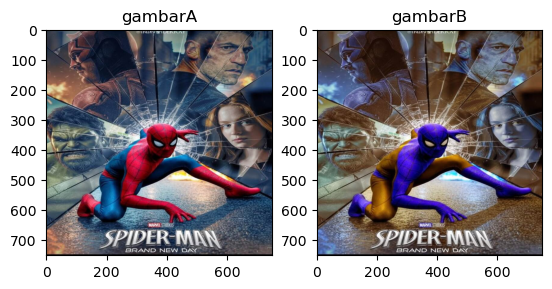

In [ ]:
brand1 = plt.imread("brandnewday.jpg")

plt.subplot(1,2,1)
plt.imshow(brand1)
plt.title("gambarA")

brand2 = cv2.imread("brandnewday.jpg")

plt.subplot(1,2,2)
plt.imshow(brand2 )
plt.title("gambarB")


Ketika cv2.imread() membaca gambar, ia menyimpan pixel dalam format BGR, namun plt.imshow() menginterpretasikan array sebagai RGB. Akibatnya gambar B akan terlihat dengan warna yang "terbalik"/distorsi, terutama pada area merah dan biru.

Text(0.5, 1.0, 'gambarB')

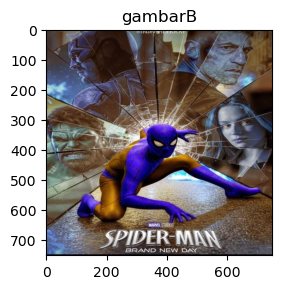

In [59]:
brand2 = cv2.imread("brandnewday.jpg")

plt.subplot(1,2,2)
plt.imshow(brand2)
plt.title("gambarB")

Text(0.5, 1.0, 'grayscale')

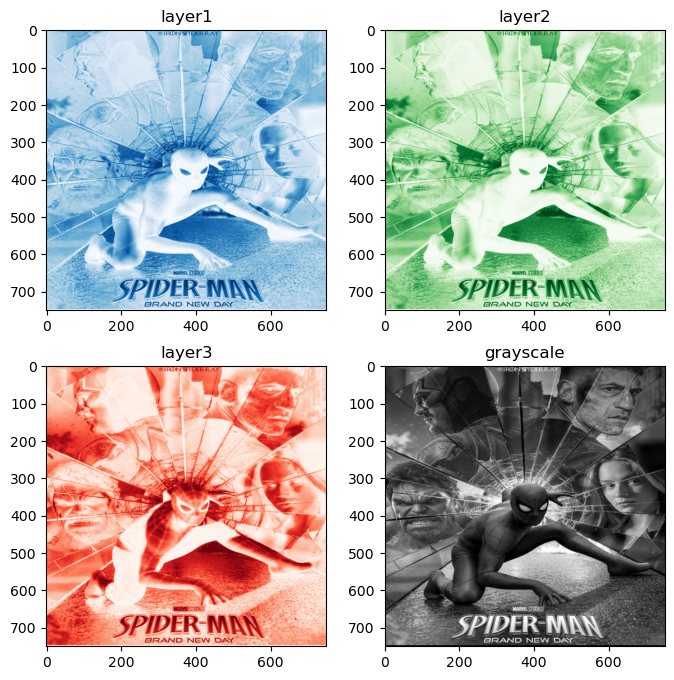

In [60]:
plt.figure(figsize=(8, 8))

plt.subplot(2,2,1)
plt.imshow(brand2 [ :,:,0], cmap ="Blues" )
plt.title("layer1")

plt.subplot(2,2,2)
plt.imshow(brand2[:,:,1], cmap ="Greens")
plt.title("layer2")

plt.subplot(2,2,3)
plt.imshow(brand2[:,:,2], cmap="Reds" )
plt.title("layer3")

gray2 = cv2.cvtColor(brand2, cv2.COLOR_BGR2GRAY)
plt.subplot(2,2,4)
plt.imshow(gray2, cmap = "gray")
plt.title("grayscale")

Ketiga layer channel menunjukkan bahwa setiap warna dalam gambar sesungguhnya adalah hasil kombinasi tiga komponen intensitas (B, G, R). Memisahkannya membantu kita memahami dominasi warna di setiap area gambar. Sementara itu, grayscale adalah representasi tunggal yang merangkum persepsi kecerahan dari ketiga channel tersebut sesuai sensitivitas mata manusia — menjadikannya representasi yang paling "alami" dalam satu dimensi.

Text(0.5, 1.0, 'A 3')

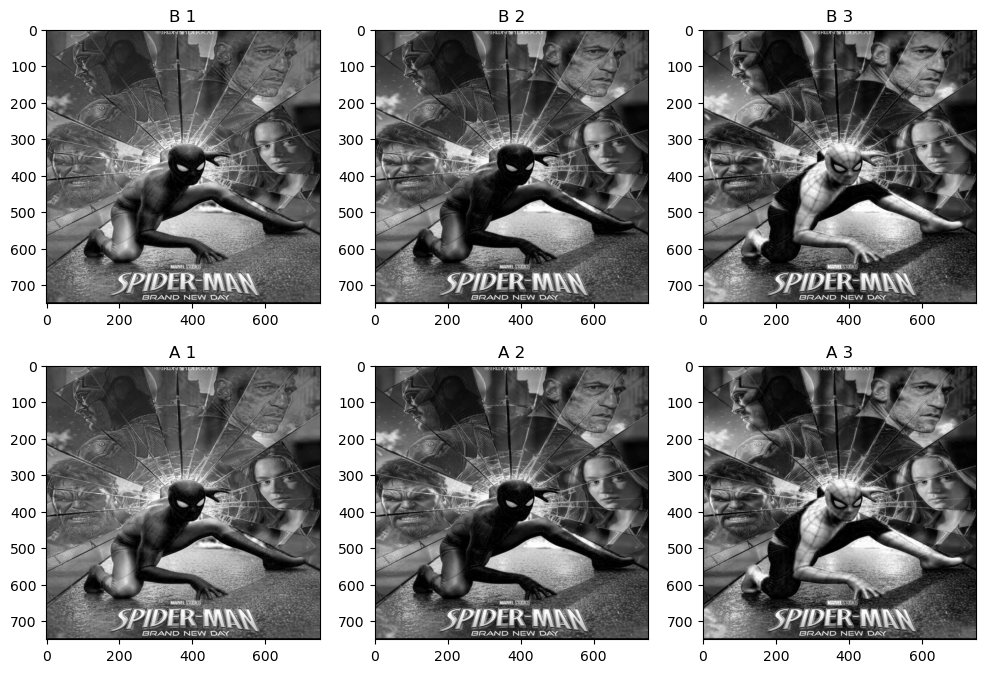

In [172]:

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.imshow(brand2[:,:,0], cmap = "gray")
plt.title("B 1" )

plt.subplot(2,3,2)
plt.imshow(brand2[:,:,1], cmap = "gray" )
plt.title("B 2" )

plt.subplot(2,3,3)
plt.imshow(brand2[:,:,2], cmap = "gray")
plt.title("B 3" )

plt.subplot(2,3,4)
plt.imshow(brand1[:,:,2], cmap = "gray")
plt.title("A 1" )

plt.subplot(2,3,5)
plt.imshow(brand1[:,:,1], cmap = "gray")
plt.title("A 2" )

plt.subplot(2,3,6)
plt.imshow(brand1[:,:,0], cmap = "gray")
plt.title("A 3" )

Karena kedua gambar dibaca dari file yang sama, nilai piksel channel biru-nya identik. Perbedaan hanya pada cara pengindeksan: cv2 mengaksesnya di index [0], sedangkan plt di index [2]. Hasil visualisasi grayscale-nya seharusnya tampak sama persis.Channel hijau adalah satu-satunya channel yang tidak bergeser posisinya antara BGR dan RGB — selalu berada di tengah (index 1). Oleh karena itu B2 dan A2 langsung mengakses data yang sama tanpa perlu penyesuaian indeks. Channel ini juga mengandung informasi luminance terbanyak, sehingga grayscale-nya paling detail dan kaya tekstur.Channel merah diakses di index [2] pada cv2 dan index [0] pada plt, namun nilainya identik karena berasal dari file yang sama. Channel ini paling sensitif terhadap warna-warna hangat, sehingga cocok digunakan untuk deteksi kulit atau objek berwarna merah/oranye dalam computer vision.Ini membuktikan bahwa cv2.imread dan plt.imread membaca data piksel yang identik dari file yang sama, namun menyusunnya dalam urutan channel yang berlawanan (BGR vs RGB). Selama pengindeksan dilakukan dengan benar dan konsisten, hasil ekstraksi channel individual akan selalu menghasilkan visualisasi grayscale yang sama. Pemahaman ini sangat krusial dalam pengolahan citra agar tidak terjadi kesalahan interpretasi warna saat berpindah antara library OpenCV dan Matplotlib.

Text(0.5, 1.0, 'grayscale')

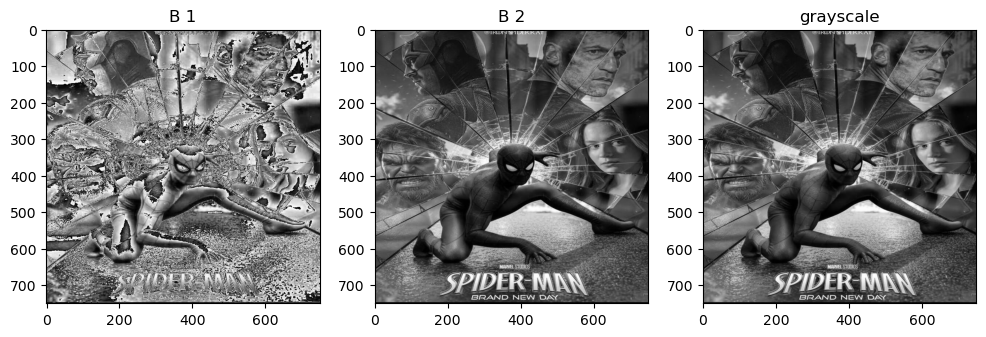

In [189]:
plt.figure(figsize=(12, 8))
graymanual = brand1.copy()
graymanual = (brand1[:,:,0] +brand1[:,:,1] + brand1[:,:,2])/3
graymanual2 = brand2.copy()
graymanual2 = 0.299* brand2[:,:,0] + 0.587 * brand2[:,:,1] + 0.114*brand2[:,:,2]

plt.subplot(1,3,1)
plt.imshow(graymanual, cmap = "gray")
plt.title("B 1" )

plt.subplot(1,3,2)
plt.imshow(graymanual2, cmap = "gray" )
plt.title("B 2" )

gray2 = cv2.cvtColor(brand2, cv2.COLOR_BGR2GRAY)
plt.subplot(1,3,3)
plt.imshow(gray2, cmap = "gray")
plt.title("grayscale")

B1 (Simple Average) menghasilkan grayscale yang rata dan flat karena mengabaikan perbedaan sensitivitas mata manusia terhadap tiap warna. B2 (Weighted Manual) memiliki niat yang benar namun gagal karena tidak menyesuaikan bobot dengan format BGR milik OpenCV, sehingga bobot Blue dan Red justru tertukar menghasilkan tampilan yang tidak natural. Grayscale OpenCV adalah yang paling akurat dan natural karena sudah memahami format BGR secara internal dan menerapkan bobot luminance sesuai standar persepsi visual manusia (ITU-R BT.601). Pelajaran utamanya: dalam pengolahan citra, memahami format channel (RGB vs BGR) adalah hal yang tidak boleh diabaikan, bahkan dalam operasi sesederhana konversi grayscale.

Text(0.5, 1.0, 'grayscale')

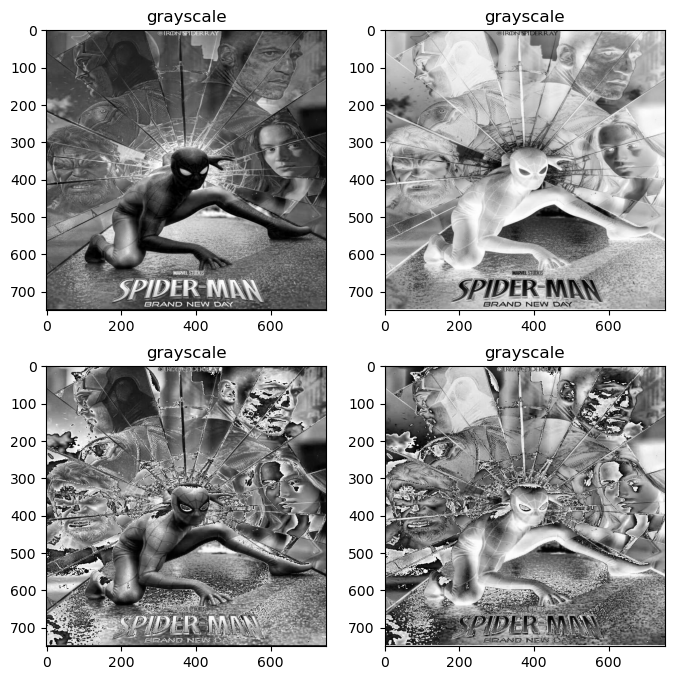

In [ ]:
plt.figure(figsize=(8, 8))

gray2 = cv2.cvtColor(brand2, cv2.COLOR_BGR2GRAY)
plt.subplot(2,2,1)
plt.imshow(brand2[:,:,0], cmap = "gray")
plt.title("grayscale")

negatif = 255 - gray2
plt.subplot(2,2,2)
plt.imshow(negatif, cmap = "gray")
plt.title("Ngeatif")

GN = gray2 - negatif
plt.subplot(2,2,3)
plt.imshow(GN, cmap = "gray")
plt.title("G-N")

NG = negatif - gray2
plt.subplot(2,2,4)
plt.imshow(NG, cmap = "gray")
plt.title("N-G")



Subplot 1 sebenarnya menampilkan channel biru, bukan grayscale sejati. Subplot 2 (Negatif) adalah inversi sempurna yang membalik seluruh hierarki kecerahan. Subplot 3 (G-N) hanya mempertahankan informasi dari piksel terang karena piksel gelap underflow ke nol. Subplot 4 (N-G) adalah kebalikannya — hanya area gelap yang bertahan. Secara keseluruhan, eksperimen ini mendemonstrasikan bagaimana operasi aritmatika sederhana pada array uint8 dapat menghasilkan efek visual yang dramatis, namun juga menunjukkan pentingnya memahami batasan tipe data (uint8 clipping) agar hasil interpretasi tidak keliru.

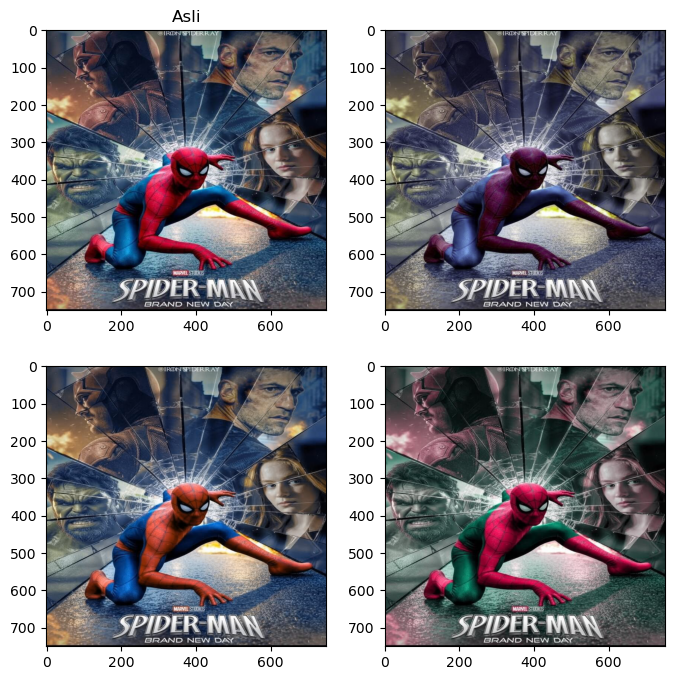

In [82]:
img1 = plt.imread('brandnewday.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
r, g, b = cv2.split(img1)

img_r_gray = cv2.merge([gray1, g, b])
img_g_gray = cv2.merge([r, gray1, b])
img_b_gray = cv2.merge([r, g, gray1])

plt.figure(figsize=(8, 8))

plt.subplot(2,2,1)
plt.imshow(img1)
plt.title("Asli")

plt.subplot(2,2,2)
plt.imshow(img_r_gray)

plt.subplot(2,2,3)
plt.imshow(img_g_gray)

plt.subplot(2,2,4)
plt.imshow(img_b_gray)

Mengganti channel R dengan grayscale menghilangkan kontribusi warna hangat dari gambar. Karena grayscale adalah nilai tengah dari semua warna, channel R kehilangan "kepribadiannya". Warna yang tersisa (G+B) mendominasi, sehingga gambar tampak kebiru-biruan dan kehijau-hijauan secara keseluruhan — warna-warna komplementer dari merah.Mengganti G dengan gray1 berarti mengganti channel paling berpengaruh terhadap persepsi kecerahan. Selain itu, mata manusia paling sensitif terhadap hijau, sehingga perubahan pada channel ini paling mudah terdeteksi secara visual. Warna yang tersisa (R+B tanpa G) menghasilkan dominasi magenta, yaitu warna komplementer dari hijau.Mata manusia paling tidak sensitif terhadap biru, sehingga penggantian channel B menghasilkan perubahan yang paling tidak mencolok. Warna yang tersisa (R+G tanpa B asli) cenderung ke arah kuning — warna komplementer dari biru.

Text(0.5, 1.0, 'gambarB')

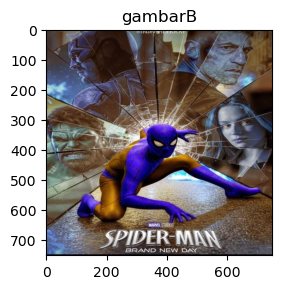

In [77]:
brand2 = cv2.imread("brandnewday.jpg")

plt.subplot(1,2,2)
plt.imshow(brand2)
plt.title("gambarB")

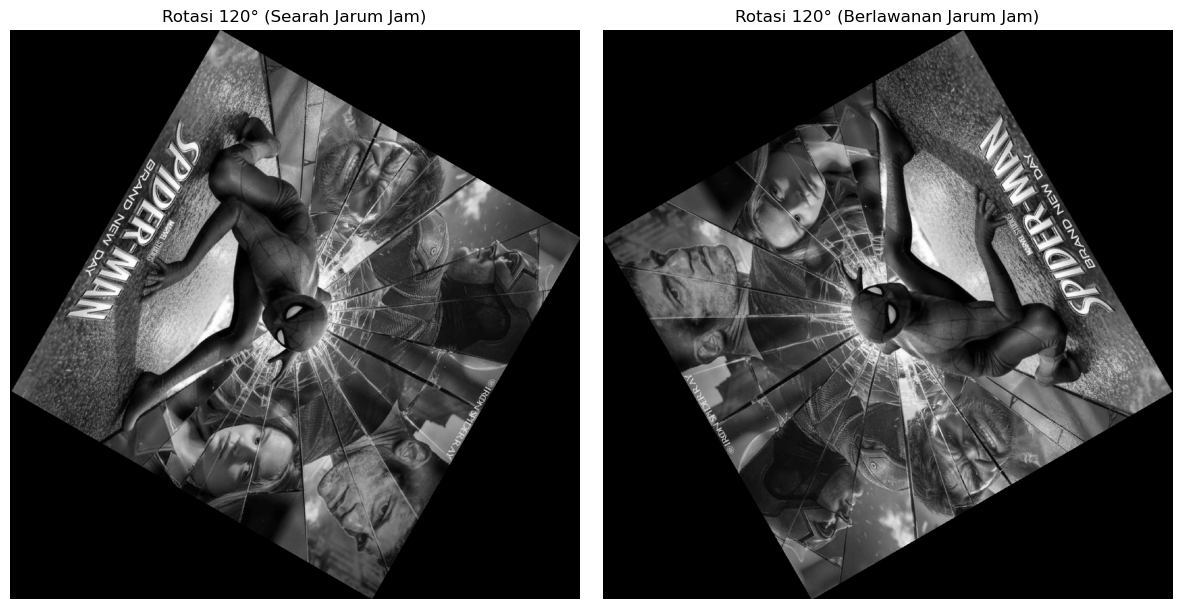

In [ ]:
brand2 = cv2.imread("brandnewday.jpg")
gray2  = cv2.cvtColor(brand2, cv2.COLOR_BGR2GRAY)

def rotasi_sudut(img, derajat):
    h, w = img.shape
    sudut_rad = np.deg2rad(derajat)

    cos_a = abs(np.cos(sudut_rad))
    sin_a = abs(np.sin(sudut_rad))
    w_baru = int(h * sin_a + w * cos_a)
    h_baru = int(h * cos_a + w * sin_a)

    cx_lama, cy_lama = w / 2, h / 2
    cx_baru, cy_baru = w_baru / 2, h_baru / 2

    hasil = np.zeros((h_baru, w_baru), dtype=img.dtype)

    for i in range(h_baru):
        for j in range(w_baru):
            x = (j - cx_baru) *  np.cos(sudut_rad) + (i - cy_baru) * np.sin(sudut_rad) + cx_lama
            y = (j - cx_baru) * -np.sin(sudut_rad) + (i - cy_baru) * np.cos(sudut_rad) + cy_lama

            x, y = int(round(x)), int(round(y))

            if 0 <= x < w and 0 <= y < h:
                hasil[i, j] = img[y, x]

    return hasil

rotasi_cw  = rotasi_sudut(gray2, 120)

rotasi_ccw = rotasi_sudut(gray2, 240)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rotasi_cw, cmap='gray')
plt.title("Searah Jarum Jam)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rotasi_ccw, cmap='gray')
plt.title("Berlawanan Jarum Jam)")
plt.axis('off')

plt.tight_layout()
plt.show()

Fungsi rotasi_sudut() mengimplementasikan rotasi citra dari prinsip pertama menggunakan inverse mapping dan nearest neighbor interpolation. Rotasi 120° (CW) dan 240° (CCW) menghasilkan gambar yang saling mencerminkan satu sama lain, dengan dimensi canvas yang identik karena penggunaan abs() pada nilai cos dan sin. Meskipun secara konsep benar, implementasi loop Python ini sangat tidak efisien untuk gambar beresolusi tinggi dan menghasilkan tepi yang bergerigi akibat nearest neighbor. Dalam praktik nyata, cv2.warpAffine() adalah pilihan yang jauh lebih optimal karena diimplementasikan dalam C++ dengan interpolasi yang lebih halus.

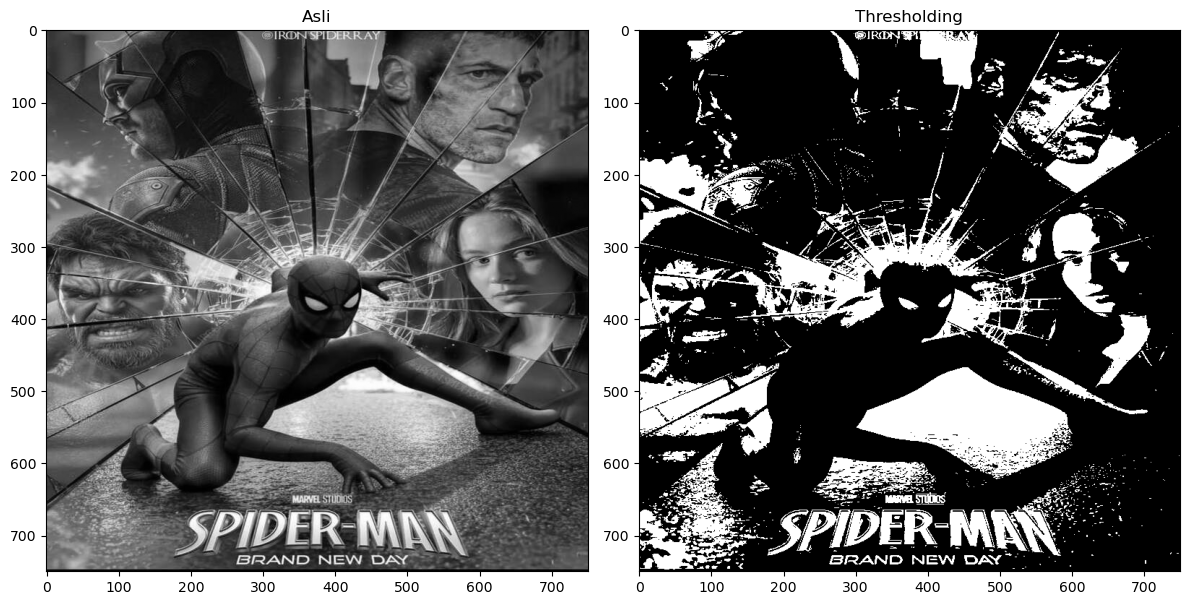

In [84]:
brand2 = cv2.imread("brandnewday.jpg")
gray2  = cv2.cvtColor(brand2, cv2.COLOR_BGR2GRAY)

threshold = 120

hasil_thresh = np.zeros_like(gray2)         
hasil_thresh[gray2 >= threshold] = 255       
hasil_thresh[gray2 <  threshold] = 0         

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray2, cmap='gray')
plt.title("Asli")

plt.subplot(1, 2, 2)
plt.imshow(hasil_thresh, cmap='gray')
plt.title("Thresholding")

plt.tight_layout()
plt.show()

melakukan proses segmentasi citra menggunakan teknik thresholding berujuan mengubah citra grayscale menjadi citra biner (hitam–putih) berdasarkan nilai ambang tertentu.

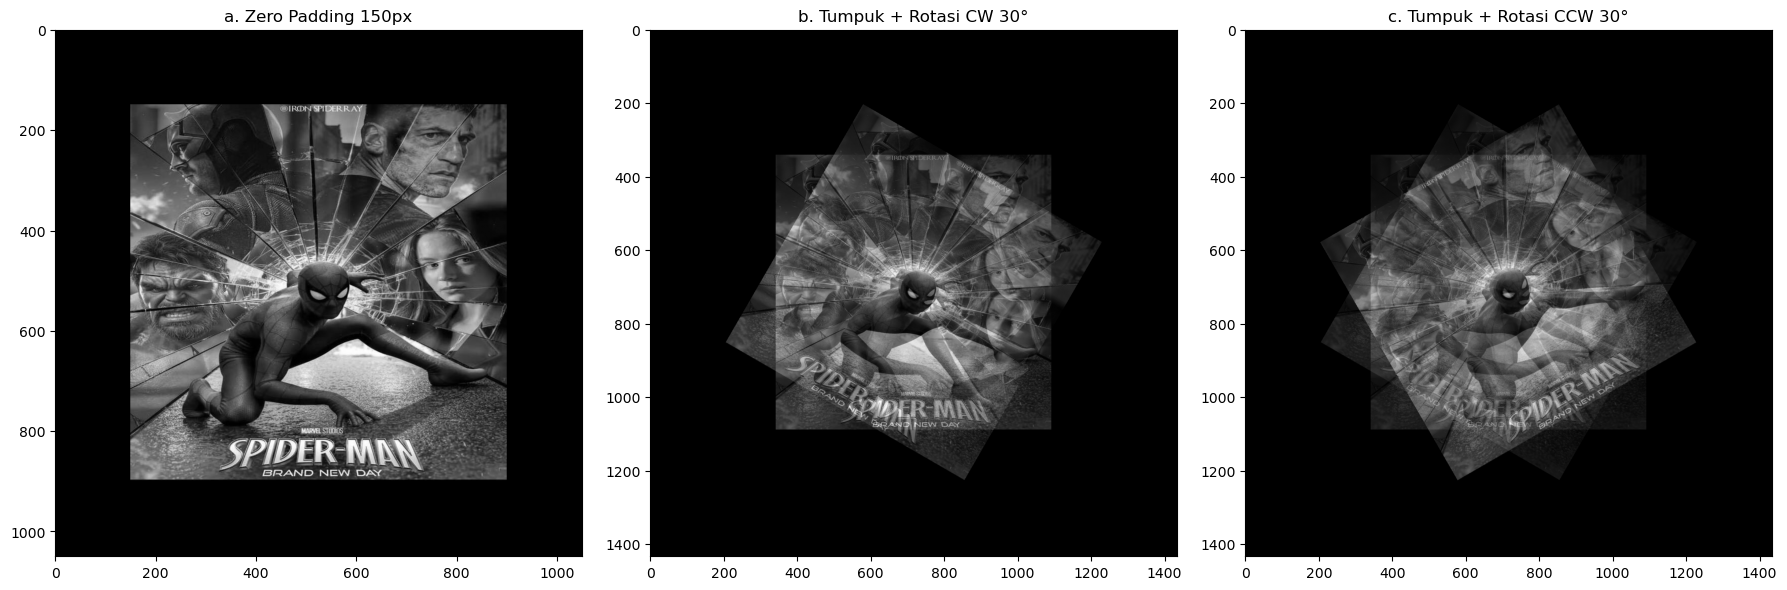

In [89]:
brand2 = cv2.imread("brandnewday.jpg")
gray2  = cv2.cvtColor(brand2, cv2.COLOR_BGR2GRAY)

pad = 150
citra_a = np.pad(gray2, pad_width=pad, mode='constant', constant_values=0)

def rotasi_manual(img, derajat):
    h, w   = img.shape
    sudut  = np.deg2rad(derajat)
    cx, cy = w / 2, h / 2

    cos_a = np.cos(sudut)
    sin_a = np.sin(sudut)

    w_baru = int(abs(h * sin_a) + abs(w * cos_a))
    h_baru = int(abs(h * cos_a) + abs(w * sin_a))

    cx_baru = w_baru / 2
    cy_baru = h_baru / 2

    hasil = np.zeros((h_baru, w_baru), dtype=np.float32)  # ✓ float32

    i_arr, j_arr = np.mgrid[0:h_baru, 0:w_baru]

    x_src = (j_arr - cx_baru) * cos_a + (i_arr - cy_baru) * sin_a + cx
    y_src = -(j_arr - cx_baru) * sin_a + (i_arr - cy_baru) * cos_a + cy

    x_src = np.round(x_src).astype(int)
    y_src = np.round(y_src).astype(int)

    mask = (x_src >= 0) & (x_src < w) & (y_src >= 0) & (y_src < h)
    hasil[i_arr[mask], j_arr[mask]] = img[y_src[mask], x_src[mask]]

    return hasil 

def tempel_tengah(kanvas, img):
    h_k, w_k = kanvas.shape
    h_i, w_i = img.shape
    y0 = (h_k - h_i) // 2
    x0 = (w_k - w_i) // 2
    kanvas[y0:y0+h_i, x0:x0+w_i] = img
    return kanvas

def tumpuk(img1, img2):
    h = max(img1.shape[0], img2.shape[0])
    w = max(img1.shape[1], img2.shape[1])

    k1 = np.zeros((h, w), dtype=np.float32)
    k2 = np.zeros((h, w), dtype=np.float32)

    k1 = tempel_tengah(k1, img1.astype(np.float32))
    k2 = tempel_tengah(k2, img2.astype(np.float32))

    hasil = (k1 / 2 + k2 / 2)
    return np.clip(hasil, 0, 255).astype(np.uint8)

rot_cw  = rotasi_manual(citra_a,  30)
citra_b = tumpuk(citra_a, rot_cw)

rot_ccw = rotasi_manual(citra_a, -30)
citra_c = tumpuk(citra_b, rot_ccw)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(citra_a, cmap='gray')
plt.title("a. Zero Padding 150px")

plt.subplot(1, 3, 2)
plt.imshow(citra_b, cmap='gray')
plt.title("b. Tumpuk + Rotasi CW 30°")

plt.subplot(1, 3, 3)
plt.imshow(citra_c, cmap='gray')
plt.title("c. Tumpuk + Rotasi CCW 30°")

plt.tight_layout()
plt.show()

Proses ini menghilangkan informasi warna dan menyisakan intensitas cahaya saja, sehingga perhitungan menjadi lebih sederhana dan fokus pada struktur objek. Setelah itu dilakukan zero padding sebesar 150 piksel di setiap sisi. Langkah ini sangat penting karena tanpa padding, ketika citra diputar, bagian sudut akan keluar dari frame dan terpotong. Dengan adanya padding, citra memiliki ruang tambahan sehingga hasil rotasi tetap utuh dan tidak kehilangan informasi di bagian tepi.

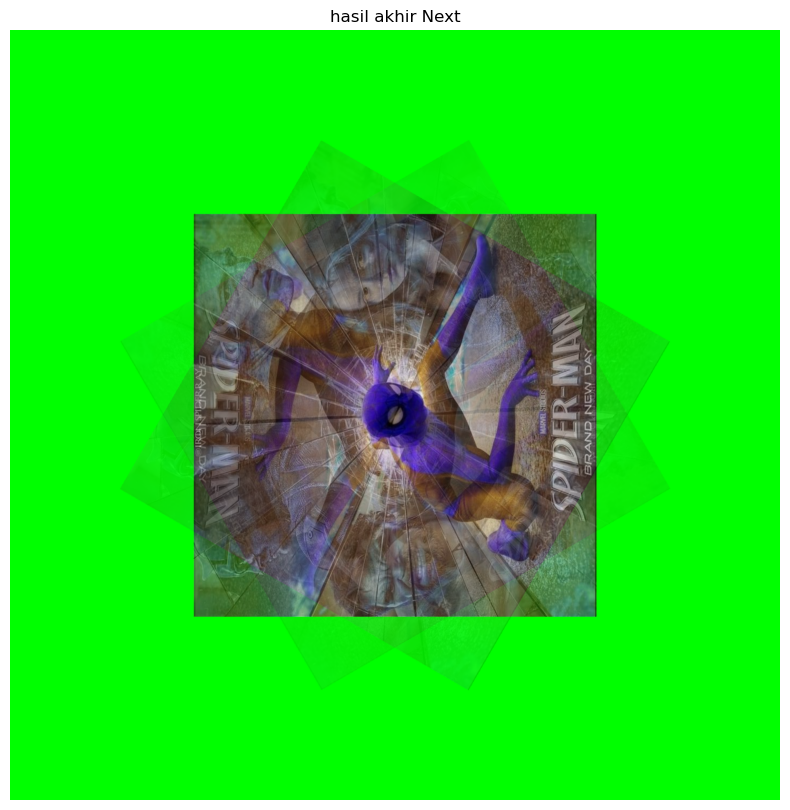

In [26]:
brand2 = cv2.imread("brandnewday.jpg")
brand2_rgb = cv2.cvtColor(brand2, cv2.COLOR_BGR2RGB)

pad = 150
h, w, c = brand2_rgb.shape

citra_a = np.zeros((h + pad*2, w + pad*2, 3), dtype=brand2_rgb.dtype)
citra_a[:, :] = [0, 255, 0]  
citra_a[pad:pad+h, pad:pad+w] = brand2_rgb

def rotasi_rgb(img, derajat):
    h, w, _ = img.shape
    sudut = np.deg2rad(derajat)
    cx, cy = w / 2, h / 2

    cos_a = np.cos(sudut)
    sin_a = np.sin(sudut)

    w_baru = int(abs(h * sin_a) + abs(w * cos_a))
    h_baru = int(abs(h * cos_a) + abs(w * sin_a))
    cx_baru, cy_baru = w_baru / 2, h_baru / 2

    hasil = np.zeros((h_baru, w_baru, 3), dtype=img.dtype)
    hasil[:, :] = [0, 255, 0] 

    i_arr, j_arr = np.mgrid[0:h_baru, 0:w_baru]

    x_src = (j_arr - cx_baru) * cos_a + (i_arr - cy_baru) * sin_a + cx
    y_src = (j_arr - cx_baru) * -sin_a + (i_arr - cy_baru) * cos_a + cy

    x_src = np.round(x_src).astype(int)
    y_src = np.round(y_src).astype(int)

    mask = (x_src >= 0) & (x_src < w) & (y_src >= 0) & (y_src < h)
    hasil[i_arr[mask], j_arr[mask]] = img[y_src[mask], x_src[mask]]

    return hasil

def tumpuk_rgb(img1, img2):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    H = max(h1, h2)
    W = max(w1, w2)

    k1 = np.full((H, W, 3), [0, 255, 0], dtype=np.int32)
    k2 = np.full((H, W, 3), [0, 255, 0], dtype=np.int32)

    y1, x1 = (H - h1) // 2, (W - w1) // 2
    y2, x2 = (H - h2) // 2, (W - w2) // 2

    k1[y1:y1+h1, x1:x1+w1] = img1.astype(np.int32)
    k2[y2:y2+h2, x2:x2+w2] = img2.astype(np.int32)

    hasil = (k1 + k2) // 2
    return np.clip(hasil, 0, 255).astype(np.uint8)

sudut_list = [30, -30, 60, -60, 90, -90]

hasil = citra_a.copy()
for sudut in sudut_list:
    rot = rotasi_rgb(citra_a, sudut)
    hasil = tumpuk_rgb(hasil, rot)

hasil_akhir = cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(hasil_akhir)
plt.title("hasil akhir Next")
plt.axis('off') 
plt.show()

merupakan pengembangan dari versi grayscale sebelumnya, tetapi sekarang bekerja pada citra berwarna (RGB) dengan tambahan efek visual yang lebih kompleks karena menggunakan banyak rotasi dan proses penumpukan berulang.

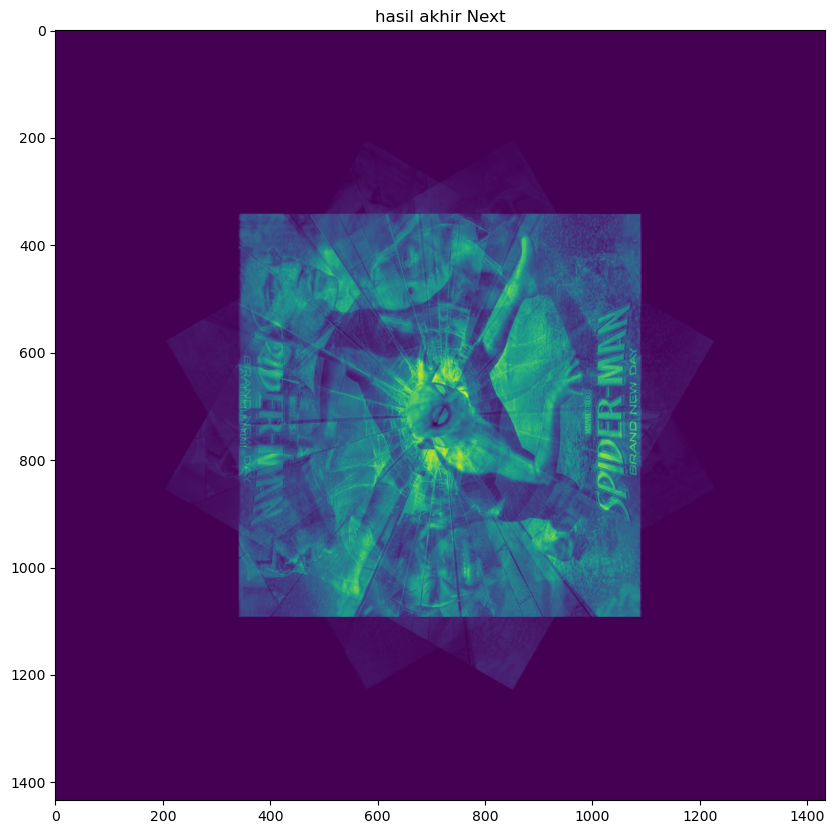

In [33]:
brand2 = cv2.imread("brandnewday.jpg")
brand2_rgb = cv2.cvtColor(brand2, cv2.COLOR_BGR2RGB)

pad = 150
h, w, c = brand2_rgb.shape

citra_a = np.zeros((h + pad*2, w + pad*2, 3), dtype=brand2_rgb.dtype)
citra_a[:, :] = [0, 255, 0]  
citra_a[pad:pad+h, pad:pad+w] = brand2_rgb

def rotasi_rgb(img, derajat):
    h, w, _ = img.shape
    sudut = np.deg2rad(derajat)
    cx, cy = w / 2, h / 2

    cos_a = np.cos(sudut)
    sin_a = np.sin(sudut)

    w_baru = int(abs(h * sin_a) + abs(w * cos_a))
    h_baru = int(abs(h * cos_a) + abs(w * sin_a))
    cx_baru, cy_baru = w_baru / 2, h_baru / 2

    hasil = np.zeros((h_baru, w_baru, 3), dtype=img.dtype)
    hasil[:, :] = [0, 255, 0] 

    i_arr, j_arr = np.mgrid[0:h_baru, 0:w_baru]

    x_src = (j_arr - cx_baru) * cos_a + (i_arr - cy_baru) * sin_a + cx
    y_src = (j_arr - cx_baru) * -sin_a + (i_arr - cy_baru) * cos_a + cy

    x_src = np.round(x_src).astype(int)
    y_src = np.round(y_src).astype(int)

    mask = (x_src >= 0) & (x_src < w) & (y_src >= 0) & (y_src < h)
    hasil[i_arr[mask], j_arr[mask]] = img[y_src[mask], x_src[mask]]

    return hasil

def tumpuk_rgb(img1, img2):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    H = max(h1, h2)
    W = max(w1, w2)

    k1 = np.full((H, W, 3), [0, 255, 0], dtype=np.int32)
    k2 = np.full((H, W, 3), [0, 255, 0], dtype=np.int32)

    y1, x1 = (H - h1) // 2, (W - w1) // 2
    y2, x2 = (H - h2) // 2, (W - w2) // 2

    k1[y1:y1+h1, x1:x1+w1] = img1.astype(np.int32)
    k2[y2:y2+h2, x2:x2+w2] = img2.astype(np.int32)

    hasil = (k1 + k2) // 2
    return np.clip(hasil, 0, 255).astype(np.uint8)

sudut_list = [30, -30, 60, -60, 90, -90]

hasil = citra_a.copy()
for sudut in sudut_list:
    rot = rotasi_rgb(citra_a, sudut)
    hasil = tumpuk_rgb(hasil, rot)

hasil_akhir = cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(hasil_akhir[:,:,2])
plt.title("hasil akhir Next")
plt.show()

menggunakan alur yang sama seperti sebelumnya—membaca citra, mengubah ke RGB, menambahkan padding berwarna hijau, melakukan rotasi manual, lalu menumpuk (blending) beberapa hasil rotasi. Namun ada satu perbedaan penting di bagian visualisasi akhir: yang ditampilkan bukan citra RGB penuh, melainkan hanya satu channel warna, yaitu channel indeks ke-2 ([:,:,2]).